<a href="https://colab.research.google.com/github/vzyhug/200123035_14DHTH07_DL/blob/main/ANN/VuDuyHung_ANN_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

them cac thu vien

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

Bai mau : Trong dia & Vanh dai

Block 1 : khoi tao cac diem du lieu theo Phan phoi chuan

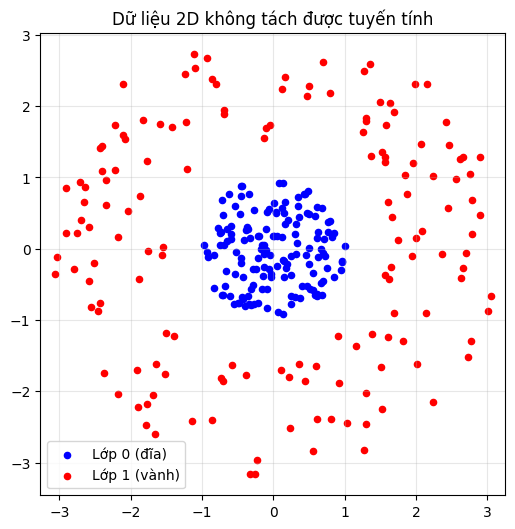

In [6]:
# khoi tao du lieu ben trong dia tron
def generate_data_disk(num_samples,r_max=1.0):
  u = np.random.uniform(0,1,num_samples)
  theta = np.random.uniform(0,2*np.pi,num_samples)
  r=r_max*np.sqrt(u)
  return np.column_stack((r*np.cos(theta),r*np.sin(theta)))
# khoi tao du lieu vanh dai quanh dia tron
def generate_data_ring(num_samples,r_in=1.5,r_out=2.5):
  u = np.random.uniform(0,1,num_samples)
  theta = np.random.uniform(0,2*np.pi,num_samples)
  r= np.sqrt(u*(r_out*np.pi)+r_in**2)
  return np.column_stack((r*np.cos(theta),r*np.sin(theta)))
####
# so luong diem mau
n_per_class= 150
X0 = generate_data_disk(n_per_class)
X1 = generate_data_ring(n_per_class)
X = np.vstack([X0,X1])
y= np.hstack([np.zeros(n_per_class),np.ones(n_per_class)])
#
plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [7]:

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


Hồi quy Logistic


In [8]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 55.00%   (kỳ vọng quanh 50%)


Xây dựng ANN

In [9]:

class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Huấn luyện và theo dõi loss / accuracy
Ta sẽ train 500 epoch (đủ để hội tụ trên bài này) và lưu cả train loss + test accuracy qua từng epoch.

Epoch  100/500  loss=0.3195  test_acc=98.33%
Epoch  200/500  loss=0.1183  test_acc=100.00%
Epoch  300/500  loss=0.0633  test_acc=100.00%
Epoch  400/500  loss=0.0406  test_acc=100.00%
Epoch  500/500  loss=0.0282  test_acc=100.00%


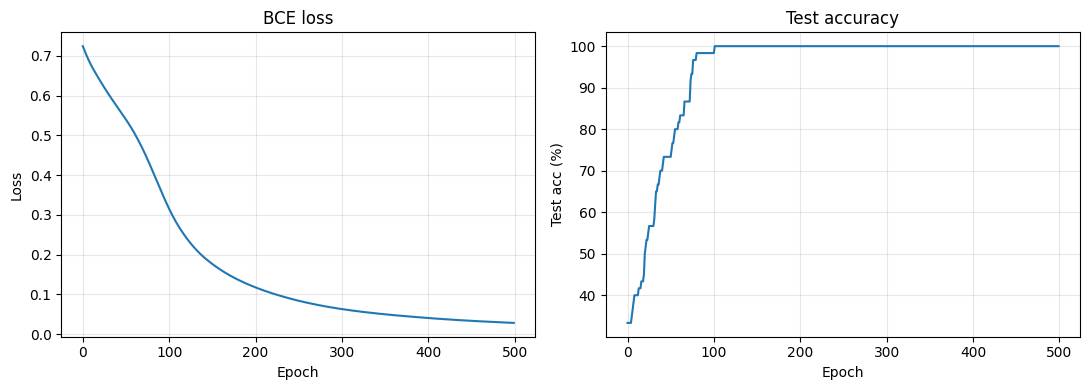

In [10]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [11]:
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 55.00% — ANN thắng đậm vì học được ranh giới phi tuyến.)


Trực quan ranh giới quyết định
Vẽ contour xác suất (không phải hard 0/1) sẽ cho ta thấy mạng "tự tin" ở vùng nào, "ngập ngừng" ở vùng nào.

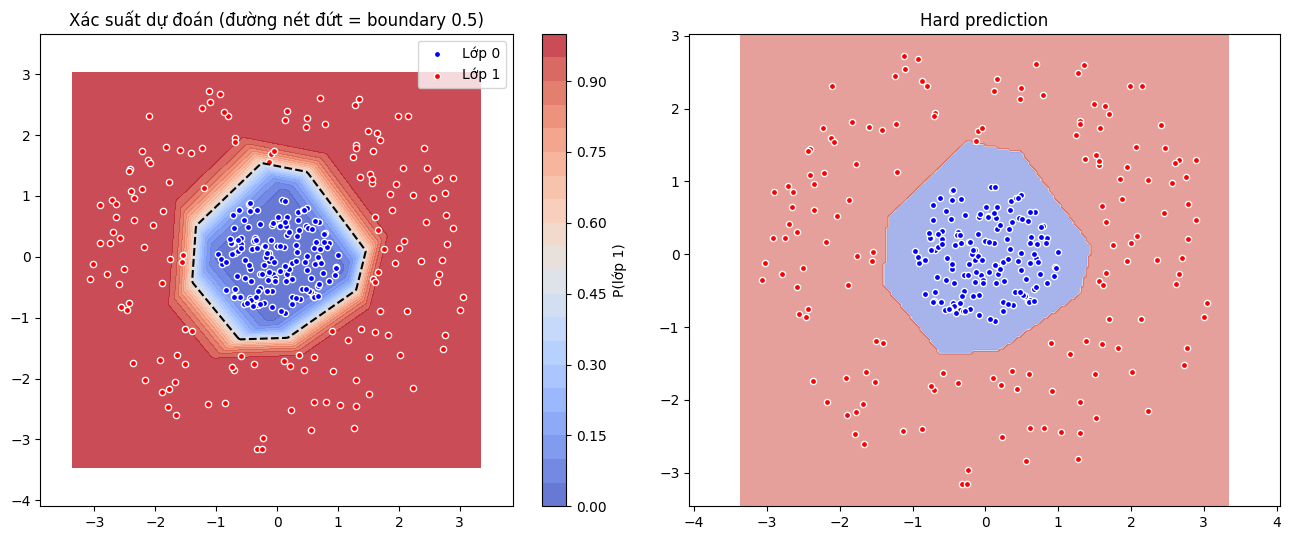

In [12]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

BÀI TẬP VỀ NHÀ

Phần 1: Thay đổi cấu trúc ANN
Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.
So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?

In [13]:
# Mô hình 1: 2 -> 4 -> 1 (Gốc)
model_4 = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())

# Mô hình 2: 2 -> 8 -> 1
model_8 = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())

# Mô hình 3: 2 -> 8 -> 6 -> 1
model_deep = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 6), nn.ReLU(),
    nn.Linear(6, 1), nn.Sigmoid()
)

models = [model_4, model_8, model_deep]
names = ["4 nodes", "8 nodes", "8+6 nodes"]

In [14]:
epochs = 500
loss_histories = []

for model in models:
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

    loss_histories.append(history)

    # Kiểm tra accuracy cuối
    model.eval()
    with torch.no_grad():
        acc = ((model(X_test) > 0.5).float() == y_test).float().mean().item()
        print(f"Mô hình {len(history)}: Loss cuối = {history[-1]:.4f}, Test Acc = {acc*100:.2f}%")

Mô hình 500: Loss cuối = 0.0177, Test Acc = 100.00%
Mô hình 500: Loss cuối = 0.0075, Test Acc = 100.00%
Mô hình 500: Loss cuối = 0.0004, Test Acc = 100.00%


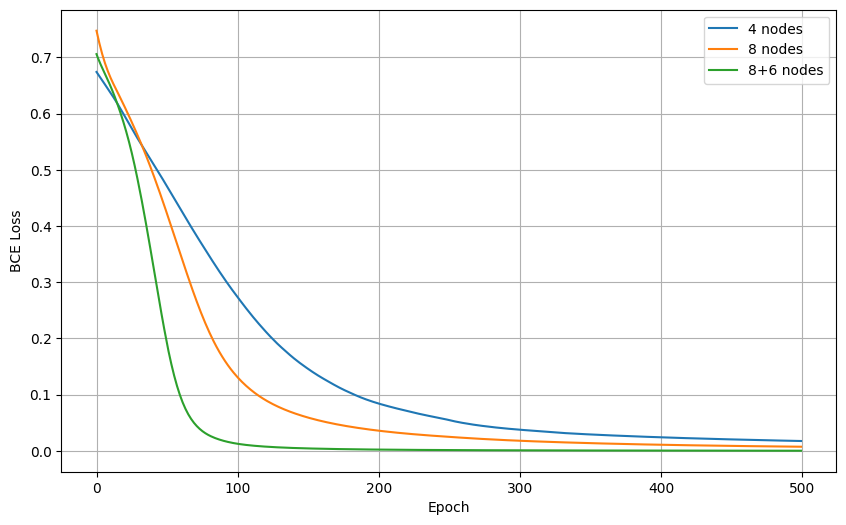

In [15]:
plt.figure(figsize=(10, 6))
for i, history in enumerate(loss_histories):
    plt.plot(history, label=names[i])
plt.xlabel('Epoch'); plt.ylabel('BCE Loss'); plt.legend(); plt.grid(True)
plt.show()

Câu hỏi : Mô hình có giảm loss nhanh hơn không ?
-- Thông thường, mô hình có nhiều tham số hơn (nhiều nút hơn hoặc nhiều lớp hơn) có khả năng học các ranh giới quyết định phức tạp nhanh hơn, dẫn đến loss giảm nhanh hơn trong giai đoạn đầu. Tuy nhiên, nếu quá lớn so với độ phức tạp của dữ liệu, nó có thể gặp khó khăn trong việc hội tụ ổn định.


Câu hỏi : Có overfitting không ?
--Với bài toán dữ liệu "Đĩa và Vành đai" (rất ít nhiễu), các mô hình này khó bị overfitting. Tuy nhiên, nếu bạn thêm quá nhiều nút (ví dụ hàng trăm nút), mô hình sẽ bắt đầu "học thuộc lòng" các điểm dữ liệu cụ thể thay vì học quy luật chung, khi đó đường loss trên tập train có thể rất thấp nhưng trên tập test sẽ bắt đầu dao động.

Có hiện tượng diminishing returns không ?
--Có. Sau khi đạt đến một ngưỡng nhất định (đủ để vẽ ranh giới phi tuyến bao quanh vòng tròn), việc thêm hàng chục hay hàng trăm nút nữa sẽ không làm tăng đáng kể độ chính xác vì mô hình đã đạt ngưỡng tối ưu (100%). Thêm tài nguyên tính toán lúc này trở nên dư thừa.